In [1]:
# @title Package
from natsort import natsorted
import numpy as np
import seaborn as sns
import pandas as pd

import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchaudio
import math
from sklearn import svm

import torchvision
import torchvision.transforms as transforms

import torchaudio.models as audio_models

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset

lib_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project44/Code'
os.chdir(lib_dir)
print('library directory: ' + lib_dir)
from modules.networks_clf import *
from modules.signal import spectro_norm, lfp_spectro
from modules.data import *
from modules.train import net_train_AnyNet_L, net_train_ViT_L, net_train_RNN_L, net_train_LC_L
from modules.metrics import accu_fun

library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code
Library directory: /content/drive/MyDrive/Project/BrainRegionId/Project44/Code


In [2]:
################################################################################
import subprocess
import sys
required = {'ONE-api', 'brain', 'ibllib'}
subprocess.check_call([sys.executable, '-m', 'pip', 'install', *required])

from one.api import ONE
from brainbox.io.one import SessionLoader, SpikeSortingLoader

from iblatlas.atlas import AllenAtlas

ba = AllenAtlas()
br = ba.regions
ba.compute_regions_volume()


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/average_template_25.nrrd Bytes: 32998960


100%|██████████| 31.470260620117188/31.470260620117188 [00:00<00:00, 446.41it/s]


Downloading: /root/Downloads/ONE/openalyx.internationalbrainlab.org/histology/ATLAS/Needles/Allen/annotation_25.nrrd Bytes: 4035363


100%|██████████| 3.848422050476074/3.848422050476074 [00:00<00:00, 141.99it/s]


In [3]:
# @title Load device
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

!nvidia-smi -L


/bin/bash: line 1: nvidia-smi: command not found


In [4]:
# Set the signal parameters
spectro_args = {
    'nfft':800,
    'power':1,
    'LFP_bound':[0, 500],
    'MUA_bound':[500, 2000],
    'spectro_img':[224, 28],
    'LFP_img':[56 * 4, 28],
    'MUA_img':[0, 28],
    'sampling_lfp':2500,
    'sampling_mua':5000,
    'Log':False,
}

dict_dir = '/content/drive/MyDrive/Project/BrainRegionId/Project37/Data/dat'
acronym_list = acronym_list_gen(dict_dir)

In [5]:
train_args = {
    'overfitting_thres':0.60,
    'lr':5e-4,
    'norm':True,
    'temp':[True, True],
}


In [6]:
Mat_dict = torch.load('/content/drive/MyDrive/Project/BrainRegionId/Project44/Result/Confusion_mat.pt', weights_only=False)

In [ ]:
from iblatlas.plots import plot_scalar_on_slice
import matplotlib.colors as mcolors
import matplotlib as mpl

In [ ]:
cmap_selec = mpl.cm.get_cmap('tab20')

/tmp/ipython-input-8-2556972733.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_selec = mpl.cm.get_cmap('tab20')


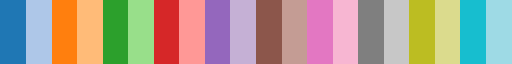

In [ ]:
cmap_selec

In [7]:
!pip install networkx
import networkx as nx

In [8]:
import copy

def modularity_separation(M, resolution, sort=True):
    G = nx.from_numpy_array(M)
    c = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
    acronym_label = []
    community_label = []
    index = []
    for c_ii, c0 in enumerate(c):
        for c_index in c0:
            community_label.append(c_ii)
            acronym_label.append(acronym_list[c_index])
            index.append(c_index)

    community_label = np.array(community_label)
    acronym_label = np.array(acronym_label)
    index = np.array(index)

    if sort == True:
        sort_index = np.argsort(index)
        community_label = community_label[sort_index]
        acronym_label = acronym_label[sort_index]
        index = index[sort_index]

    return community_label, acronym_label, index

In [9]:
resolution = 1.0
community_number = []
community_index = {}
for name in ['AnyNet', 'ViT', 'RNN']:
    X = copy.deepcopy(Mat_dict[name])
    community_label, acronym_label, index = modularity_separation(X, resolution)
    community_number.append(len(np.unique(community_label)))
    community_index[name] = community_label

communities = []
communities_label = []
communities_acronym = []
ii = 0
for community_ii_AnyNet in range(0, community_number[0]):
    for community_ii_ViT in range(0, community_number[1]):
        for community_ii_RNN in range(0, community_number[2]):
            community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                            np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                            np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
            if len(community0) > 2:
                communities.append(community0)
                communities_acronym.append(np.array(acronym_list)[community0])
                communities_label.append(ii * np.ones_like(community0))
                ii = ii + 1

In [19]:
community_label[np.argwhere(np.array(acronym_list) == "DP").flatten()]

array([1])

In [ ]:
index

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [ ]:
community_label

array([ 4,  4, 12,  1,  1,  5,  1,  1,  1,  5,  1,  1,  1,  1, 13,  1,  5,
        5,  1,  1,  3,  3,  7,  7,  7,  7,  5,  5,  5,  5,  5,  5, 14,  1,
        1,  1,  1,  1,  5,  5,  5,  1,  5,  5,  5,  5,  5,  5,  7,  7,  0,
        7,  7,  7,  7,  1,  3,  3,  3,  7,  4,  1,  1,  1,  1,  0, 15, 16,
        3,  3, 17, 18, 19,  3, 20, 21,  3,  3,  3, 22,  3,  1,  3,  3, 23,
        3,  3,  5,  5,  5,  5,  5,  5,  3,  3,  3,  3,  4,  6,  3,  3,  3,
        3,  3,  0,  7, 24,  0,  3,  3,  5,  5,  5,  5,  5,  5,  3,  3,  3,
        3,  4,  2,  4,  1,  1,  0,  8,  1,  1,  1,  1,  1,  1,  1,  1,  8,
        8,  1,  1,  1,  1,  1,  1,  1,  4,  4,  1,  1,  8,  1,  1,  1,  4,
        4,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  5,  5,
        3,  3, 25,  5,  5,  3,  3,  5,  3, 10,  5,  5,  5,  3,  5,  5,  0,
        0,  0,  3,  3,  3,  3,  0,  0,  3,  3,  3,  3,  3, 26,  4,  4,  4,
        3, 27,  0,  4,  4,  4,  4,  4,  4,  1,  4,  4,  4,  4,  1,  9,  1,
        4,  4,  4,  9,  3

In [ ]:
np.array(acronym_list)

array(['FRP1', 'FRP2/3', 'FRP5', 'FRP6a', 'MOp1', 'MOp2/3', 'MOp5',
       'MOp6a', 'MOp6b', 'MOs1', 'MOs2/3', 'MOs5', 'MOs6a', 'MOs6b',
       'SSp-n1', 'SSp-n2/3', 'SSp-n4', 'SSp-n5', 'SSp-n6a', 'SSp-n6b',
       'SSp-bfd1', 'SSp-bfd2/3', 'SSp-bfd4', 'SSp-bfd5', 'SSp-bfd6a',
       'SSp-bfd6b', 'SSp-ll1', 'SSp-ll2/3', 'SSp-ll4', 'SSp-ll5',
       'SSp-ll6a', 'SSp-ll6b', 'SSp-m1', 'SSp-m2/3', 'SSp-m4', 'SSp-m5',
       'SSp-m6a', 'SSp-m6b', 'SSp-ul1', 'SSp-ul2/3', 'SSp-ul4', 'SSp-ul5',
       'SSp-ul6a', 'SSp-ul6b', 'SSp-tr1', 'SSp-tr2/3', 'SSp-tr4',
       'SSp-tr5', 'SSp-tr6a', 'SSp-tr6b', 'SSp-un1', 'SSp-un2/3',
       'SSp-un4', 'SSp-un5', 'SSp-un6a', 'SSp-un6b', 'SSs2/3', 'SSs4',
       'SSs5', 'SSs6a', 'SSs6b', 'GU5', 'GU6a', 'VISC5', 'VISC6a',
       'VISC6b', 'AUDd2/3', 'AUDd4', 'AUDd5', 'AUDd6a', 'AUDd6b', 'AUDp4',
       'AUDp5', 'AUDp6a', 'AUDpo2/3', 'AUDpo4', 'AUDpo5', 'AUDpo6a',
       'AUDpo6b', 'AUDv5', 'AUDv6a', 'AUDv6b', 'VISal2/3', 'VISal4',
       'VISal5', 'VISal6a

In [ ]:
sum(acronym_label == np.array(acronym_list))

np.int64(472)

In [ ]:
community_dict = {}

for resolution in [0.4, 0.6, 0.8, 1.0, 1.2]:

    community_number = []
    community_index = {}
    community_dat = {}
    for name in ['AnyNet', 'ViT', 'RNN']:
        X = copy.deepcopy(Mat_dict[name])
        community_label, acronym_label, index = modularity_separation(X, resolution)
        community_number.append(len(np.unique(community_label)))
        community_index[name] = community_label

    communities = []
    communities_label = []
    communities_acronym = []
    ii = 0
    for community_ii_AnyNet in range(0, community_number[0]):
        for community_ii_ViT in range(0, community_number[1]):
            for community_ii_RNN in range(0, community_number[2]):
                community0 = np.intersect1d(np.intersect1d(np.argwhere(community_index['AnyNet'] == community_ii_AnyNet).flatten(),
                                                np.argwhere(community_index['ViT'] == community_ii_ViT).flatten()),
                                np.argwhere(community_index['RNN'] == community_ii_RNN).flatten())
                if len(community0) > 2:
                    communities.append(community0)
                    communities_acronym.append(np.array(acronym_list)[community0])
                    communities_label.append(ii * np.ones_like(community0))
                    ii = ii + 1

    communities = np.concat(communities)
    communities_label = np.concat(communities_label)
    communities_acronym = np.concat(communities_acronym)
    community_dat['communities'] = communities
    community_dat['communities_label'] = communities_label
    community_dat['communities_acronym'] = communities_acronym

    community_dict[resolution] = community_dat